# 1. Úkoly
## 1.1 SymPy

### 1.1.1 Definice symbolů
- Definujte symboly `a` a `b`.
- Definujte symboly `c` a `d` jako reálná kladná čísla.

In [3]:
import sympy as sp

In [3]:
a, b = sp.symbols('a b')
c, d = sp.symbols('c d', real=True, positive=True)

### 1.1.2 Vytvoření výrazu
- Vytvořte výraz $3a + 2b - 5$.
- Vytvořte výraz $\frac{a^2}{b^2} + \cos(a^2 + b)^2 + \sin(a^2 + b)^2$.
- Vypište oba výrazy jako LaTeX.
- V obou výrazech nahraďte $a$ za $\pi$ a $b$ za $2$ a vyhodnoťte je s přesností na 10 desetinných míst.

In [4]:
vyraz1 = 3*a + 2*b - 5
vyraz2 = (a**2 / b**2) + sp.cos(a**2 + b)**2 + sp.sin(a**2 + b)**2

print(sp.latex(vyraz1))
print(sp.latex(vyraz2))

hodnota1 = vyraz1.subs({a: sp.pi, b: 2}).evalf(10)
hodnota2 = vyraz2.subs({a: sp.pi, b: 2}).evalf(10)

print("\n", hodnota1)
print(hodnota2)

3 a + 2 b - 5
\frac{a^{2}}{b^{2}} + \sin^{2}{\left(a^{2} + b \right)} + \cos^{2}{\left(a^{2} + b \right)}

 8.424777961
3.467401100


### 1.1.3 Úpravy výrazů
- Rozviňte výraz $(a + b)^5$ na jednotlivé členy (`expand`).
- Faktorizujte výraz $a^6 - b^6$.
- Zjednodušte výraz $\sin^{6}{\left(a + b \right)} + 3 \sin^{4}{\left(a + b \right)} \cos^{2}{\left(a + b \right)} + 3 \sin^{2}{\left(a + b \right)} \cos^{4}{\left(a + b \right)} + \cos^{6}{\left(a + b \right)}$.

In [6]:
rozvoj = sp.expand((a + b)**5)
print(rozvoj)

faktorizace = sp.factor(a**6 - b**6)
print("\n", faktorizace)

slozeny = sp.sin(a + b)**6 + 3*sp.sin(a + b)**4 * sp.cos(a + b)**2 + 3*sp.sin(a + b)**2 * sp.cos(a + b)**4 + sp.cos(a + b)**6
jednoduchy = sp.simplify(slozeny)
print("\n", jednoduchy)

a**5 + 5*a**4*b + 10*a**3*b**2 + 10*a**2*b**3 + 5*a*b**4 + b**5

 (a - b)*(a + b)*(a**2 - a*b + b**2)*(a**2 + a*b + b**2)

 1


### 1.1.4 Derivace a integrace
- Najděte derivaci výrazu $a^2 + 3ab + b^2$ podle `a`.
- Spočtěte $$\int_{-\infty}^{t} e^{-x^2}\,dx.$$
- Spočtěte integrál funkce $f(x, y)=1-x-y$ přes pravoúhlý trojúhelník s vrcholy $[0,0]$, $[1,0]$, $[0,1]$:
$$\int_{0}^{1}\int_{0}^{1-y}(1-x-y)\,dx\,dy.$$

In [7]:
x, y, t = sp.symbols('x y t')

derivace = sp.diff(a**2 + 3*a*b + b**2, a)
print(derivace)

integral1 = sp.integrate(sp.exp(-x**2), (x, -sp.oo, t))
print("\n", integral1)

f = 1 - x - y
integral2 = sp.integrate(f, (x, 0, 1 - y), (y, 0, 1))
print("\n", integral2)

2*a + 3*b

 sqrt(pi)*erf(t)/2 + sqrt(pi)/2

 1/6


### 1.1.5 Řešení rovnic
- Najděte řešení rovnice $a^2 - 5a + 6 = 0$ vzhledem k `a`.
- Najděte řešení soustavy rovnic $$a + b = 5, \quad a - b = 1$$ vzhledem k `a` a `b`.
- Nalezněte všechny kořeny Legendreova polynomu stupně 5. Pro vytvoření výrazu použijte `sympy.legendre()`.

In [8]:
rovnice1 = sp.Eq(a**2 - 5*a + 6, 0)
reseni1 = sp.solve(rovnice1, a)
print(reseni1)

rovnice_sys1 = sp.Eq(a + b, 5)
rovnice_sys2 = sp.Eq(a - b, 1)
reseni_sys = sp.solve((rovnice_sys1, rovnice_sys2), (a, b))
print("\n", reseni_sys)

leg_poly = sp.legendre(5, x)
koreny_leg = sp.solve(leg_poly, x)
print("\n", koreny_leg)

[2, 3]

 {a: 3, b: 2}

 [0, -sqrt(5/9 - 2*sqrt(70)/63), sqrt(5/9 - 2*sqrt(70)/63), -sqrt(2*sqrt(70)/63 + 5/9), sqrt(2*sqrt(70)/63 + 5/9)]


### 1.1.6 Generování kódu
- Vytvořte výraz $\sin(a) + \cos(b)$, vygenerujte Python funkci a vykreslete ji pomocí `matplotlib` na oblasti $a \in [0, 2\pi]$ a $b \in [0, 2\pi]$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

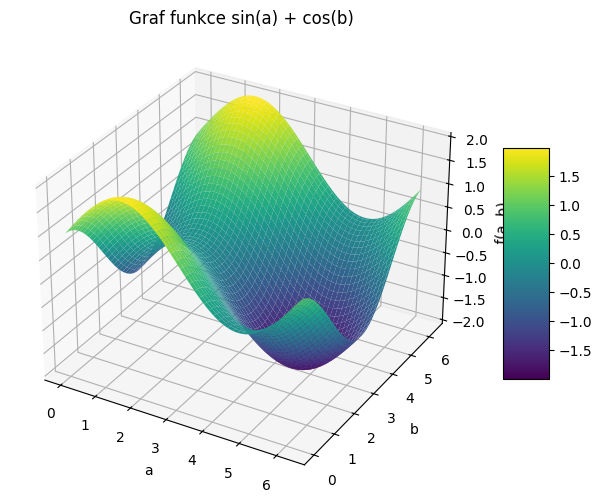

In [10]:
vyraz_plot = sp.sin(a) + sp.cos(b)
funkce = sp.lambdify((a, b), vyraz_plot, "numpy")

a_hodnoty = np.linspace(0, 2*np.pi, 100)
b_hodnoty = np.linspace(0, 2*np.pi, 100)
A, B = np.meshgrid(a_hodnoty, b_hodnoty)
Z = funkce(A, B)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, Z, cmap='viridis')

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_zlabel('f(a, b)')
ax.set_title('Graf funkce sin(a) + cos(b)')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

## 1.2 Pandas
1. Pomocí pandas načtěte data ze souboru `aku.csv` a ověřte správnost vypsáním prvních šesti řádků.
2. Vypište základní statistiky pro každý sloupec.
3. Vykreslete histogramy pomocí `seaborn` pro sloupce `A5` a `A100`.

In [1]:
import pandas as pd
import seaborn as sns

Prvních 6 řádků:


,A5,B5,C5,D5,A100,B100,C100,D100
0,"1946,5","2006,5","1881,8","1806,9","1780,4","1654,2","1663,3","1668,4"
1,"1963,5","1991,5","1890,4","1788,1","1751,4","1663,1","1641,1","1641,9"
2,"1934,3","1988,8","1865,7",1775,"1743,5","1633,3","1621,5",1620
3,"1934,8","1975,4","1880,7","1805,4","1727,4","1642,2","1610,7","1685,8"
4,"1939,9","1998,4","1861,1","1775,7","1728,8","1656,7","1624,6","1610,5"
5,"1925,9","2012,3","1887,3","1807,3","1767,5","1664,4","1604,6","1670,6"



Základní statistiky:


,A5,B5,C5,D5,A100,B100,C100,D100
count,86,86,70,79,86,86,70,79
unique,85,80,68,78,83,81,67,78
top,"1966,1","2006,5","1887,3","1788,2","1758,6","1654,2","1624,6","1683,9"
freq,2,2,2,2,2,2,2,2


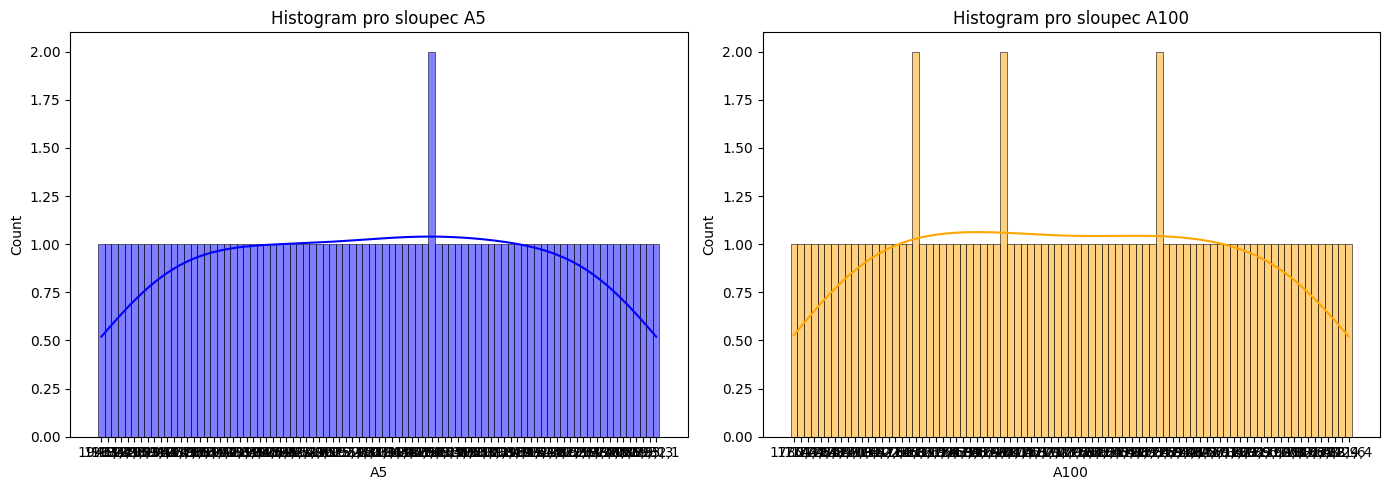

In [6]:
df = pd.read_csv('aku.csv', sep=';')
print("Prvních 6 řádků:")
display(df.head(6))

print("\nZákladní statistiky:")
display(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='A5', ax=axes[0], kde=True, color='blue')
axes[0].set_title('Histogram pro sloupec A5')

sns.histplot(data=df, x='A100', ax=axes[1], kde=True, color='orange')
axes[1].set_title('Histogram pro sloupec A100')

plt.tight_layout()
plt.show()